# benchmark.ipynb — merenje performansi upita (v1 naivna vs v2 optimizovana)

"Pre/posle" poređenje istih upita nad dve verzije baze iz `data_load.ipynb`:

* **`{db}_v1`** — naivna: 4 odvojene kolekcije (`persons`, `products`, `orders`,
  `orderlines`), **sve vrednosti stringovi**, ravna polja, **bez indeksa**.
* **`{db}_v2`** — optimizovana: `orders` sa ugnježdenim `lines[]`, tipizirano
  (int/float/datetime), prirodni ključ kao `_id`, ciljani **indeksi**.

Za svaki upit i svaku verziju: (1) opciono očisti plan cache, (2) izmeri wall-clock
**jednog** pokretanja uz puno iscrpljivanje kursora (`list(cursor)`),
(3) jednom uzmi `explain` (`executionStats`) i rekurzivno izvuci `docsExamined`,
`keysExamined`, `nReturned`, `executionTimeMillis` i da li se IGDE javlja **COLLSCAN**.

Obe verzije svakog upita vraćaju **logički isti rezultat** — razlikuje se samo izvedba
(v1 kastuje stringove inline: `$toDouble`/`$toInt`/`substr` nad string datumom; v2 koristi
tipizirana polja, ugnježdeni `lines[]` i indekse).

> Upozorenje: naivni v1 upiti (npr. q8/q10 neindeksirani $lookup) mogu biti ekstremno
> spori. Pokreni sa `--timeout` (maxTimeMS) da bi se takvi slučajevi zabeležili kao
> `DNF/timeout` umesto da blokiraju — to je takođe validan nalaz za izveštaj.

**Notebook**: izmeni `NB_*` konstante u ćeliji *Konfiguracija* i pokreni sve ćelije.
**Skripta**: `jupyter nbconvert --to script benchmark.ipynb` pa
`python benchmark.py --timeout 60000`.

In [227]:
"""Benchmark v1 (naivna) vs v2 (optimizovana) MongoDB šeme za projekat iz optimizacije upita.

Meri iste upite (q6–q10) nad bazama ``{db}_v1`` i ``{db}_v2``: wall-clock vreme jednog pokretanja + sažetak ``explain`` (executionStats). Radi i kao Jupyter notebook
(NB_* konstante) i kao samostalna skripta (argparse CLI). Rezultati u ./bench_results:
results.json (sve), results.csv (sažetak po upitu), report.md (Markdown izveštaj).
"""
from __future__ import annotations

import argparse
import csv
import json
import os
import sys
import time
from datetime import datetime
from statistics import median
from typing import Any, Callable, Optional

from pymongo import MongoClient
from pymongo.database import Database
from pymongo.errors import ExecutionTimeout, OperationFailure, PyMongoError

try:
    from tabulate import tabulate  # opciono, za lepšu poravnatu tabelu
except ImportError:  # fallback je ručno poravnanje kolona
    tabulate = None  # type: ignore[assignment]

## Konfiguracija (CLI + notebook fallback)

In [228]:
DEFAULT_URI = "mongodb://localhost:27017"
DEFAULT_DB = "ecommerce"

# Stvarne vrednosti iz dataseta (status je malim slovima).
ACTIVE_STATUS = "active"
DISCONTINUED_STATUS = "discontinued"
RATING_MIN = 4.5      # q6: "visok rating"
MIN_LINES = 6         # q9: porudžbine sa >= 6 stavki  ->  lines[MIN_LINES-1] postoji


def build_parser() -> argparse.ArgumentParser:
    p = argparse.ArgumentParser(
        description="Benchmark v1 (naivna) vs v2 (optimizovana) MongoDB šeme (jedno merenje).")
    p.add_argument("--uri", default=DEFAULT_URI, help="MongoDB URI")
    p.add_argument("--db", default=DEFAULT_DB, help="meri nad {db}_v1 i {db}_v2")
    p.add_argument("--clear-cache", action="store_true",
                   help="planCacheClear na ciljnoj kolekciji pre svakog upita")
    p.add_argument("--query", default=None, help="pokreni samo jedan upit, npr. q7")
    p.add_argument("--version", choices=["v1", "v2", "both"], default="both")
    p.add_argument("--out", default="./bench_results", help="izlazni direktorijum")
    p.add_argument("--timeout", type=int, default=0,
                   help="maxTimeMS po upitu (0 = bez limita)")
    return p


def _in_notebook() -> bool:
    return "ipykernel" in sys.modules or "ipykernel_launcher" in (sys.argv[0] if sys.argv else "")


# --- Notebook default-i (izmeni pri interaktivnom radu) ---
NB_URI = DEFAULT_URI
NB_DB = DEFAULT_DB
NB_CLEAR_CACHE = False
NB_QUERY: Optional[str] = None
NB_VERSION = "both"
NB_OUT = "./bench_results"
NB_TIMEOUT = 120_000  # preporuka: postavi npr. 60000 da naivni v1 upiti ne blokiraju


class Config:
    """Parametri pokretanja, jedinstveni za notebook i CLI."""

    def __init__(self, uri: str, db: str, clear_cache: bool,
                 query: Optional[str], version: str, out: str, timeout: int) -> None:
        self.uri = uri
        self.db = db
        self.clear_cache = clear_cache
        self.query = query
        self.version = version
        self.out = out
        self.timeout = timeout

    def __repr__(self) -> str:
        return (f"Config(uri={self.uri!r}, db={self.db!r}, clear_cache={self.clear_cache}, "
                f"query={self.query!r}, version={self.version!r}, out={self.out!r}, "
                f"timeout={self.timeout})")


def get_config(argv: Optional[list[str]] = None) -> Config:
    """Config iz NB_* (u notebook-u) ili iz CLI argumenata (kao skripta)."""
    if _in_notebook() and argv is None:
        return Config(NB_URI, NB_DB, NB_CLEAR_CACHE, NB_QUERY, NB_VERSION, NB_OUT, NB_TIMEOUT)
    a = build_parser().parse_args(argv)
    return Config(a.uri, a.db, a.clear_cache, a.query, a.version, a.out, a.timeout)

## Helperi za `explain`

`explain` se za `aggregate` i `find` razlikuje, a kod `$lookup` su metrike ugnježdene u
pod-pipeline. `walk_explain` rekurzivno prolazi ceo dict: sabira `docsExamined`/`keysExamined`
kroz **sve** pod-pipeline-ove, skuplja imena stage-ova i indeksa, beleži da li se IGDE
javlja `COLLSCAN`. Svi upiti ovde su agregacije, pa koristimo
`db.command("explain", {"aggregate": ...})`; helper `run_find_explain` pokriva i `find()`
slučaj (`cursor.explain()`) radi potpunosti.

In [229]:
def walk_explain(node: Any, acc: Optional[dict] = None) -> dict:
    """Rekurzivno prođi ceo explain dict i agregiraj metrike iz svih (pod)pipeline-ova."""
    if acc is None:
        acc = {"stages": [], "docs_examined": 0, "keys_examined": 0,
               "n_returned": [], "exec_ms": [], "indexes": [], "collscan": False}
    if isinstance(node, dict):
        for k, v in node.items():
            if k == "stage" and isinstance(v, str):
                acc["stages"].append(v)
                if v == "COLLSCAN":
                    acc["collscan"] = True
            elif k == "docsExamined" and isinstance(v, (int, float)):
                acc["docs_examined"] += v
            elif k == "keysExamined" and isinstance(v, (int, float)):
                acc["keys_examined"] += v
            elif k == "nReturned" and isinstance(v, (int, float)):
                acc["n_returned"].append(v)
            elif k in ("executionTimeMillis", "executionTimeMillisEstimate") and isinstance(v, (int, float)):
                acc["exec_ms"].append(v)
            elif k == "indexName" and isinstance(v, str):
                acc["indexes"].append(v)
            walk_explain(v, acc)
    elif isinstance(node, list):
        for item in node:
            walk_explain(item, acc)
    return acc


def _stage_label(acc: dict) -> str:
    """Kratak naziv winning plana: COLLSCAN ako se igde javlja, inače IXSCAN/FETCH/..."""
    if acc["collscan"]:
        return "COLLSCAN"
    scans = [s for s in acc["stages"] if s in ("IXSCAN", "FETCH", "COUNT_SCAN", "IDHACK", "DISTINCT_SCAN")]
    if scans:
        # zadrži redosled prvog pojavljivanja, bez duplikata
        seen: list[str] = []
        for s in scans:
            if s not in seen:
                seen.append(s)
        return "+".join(seen)
    return acc["stages"][0] if acc["stages"] else "?"


def summarize_explain(raw: dict) -> dict:
    """Sažmi sirovi explain u ravan rečnik metrika za izveštaj."""
    acc = walk_explain(raw)
    return {
        "status": "ok",
        "stage": _stage_label(acc),
        "collscan": acc["collscan"],
        "docs_examined": int(acc["docs_examined"]),
        "keys_examined": int(acc["keys_examined"]),
        "n_returned": max(acc["n_returned"]) if acc["n_returned"] else None,
        "execution_time_ms": max(acc["exec_ms"]) if acc["exec_ms"] else None,
        "indexes": sorted(set(acc["indexes"])),
    }


def run_explain(db: Database, coll_name: str, pipeline: list[dict], timeout_ms: int) -> dict:
    """explain(executionStats) za aggregate pipeline. Greške/timeout -> {status: DNF}."""
    cmd: dict[str, Any] = {
        "explain": {"aggregate": coll_name, "pipeline": pipeline,
                    "cursor": {}, "allowDiskUse": True},
        "verbosity": "executionStats",
    }
    if timeout_ms and timeout_ms > 0:
        cmd["maxTimeMS"] = timeout_ms
    try:
        raw = db.command(cmd)
    except (ExecutionTimeout, OperationFailure, PyMongoError) as exc:
        return {"status": "DNF", "error": f"{type(exc).__name__}: {exc}"}
    return summarize_explain(raw)


def run_find_explain(cursor, timeout_ms: int) -> dict:
    """explain za find() kursor (radi potpunosti — q6–q10 su agregacije)."""
    try:
        raw = cursor.explain()
    except (ExecutionTimeout, OperationFailure, PyMongoError) as exc:
        return {"status": "DNF", "error": f"{type(exc).__name__}: {exc}"}
    return summarize_explain(raw)

## Merenje (wall-clock) + plan cache

In [230]:
def clear_plan_cache(db: Database, coll_name: str) -> None:
    """planCacheClear na ciljnoj kolekciji (ignoriši ako nema keša)."""
    try:
        db.command("planCacheClear", coll_name)
    except PyMongoError:
        pass


def measure(db: Database, coll_name: str, pipeline: list[dict], timeout_ms: int) -> dict:
    """Pokreni aggregate JEDNOM; meri wall-clock oko punog list(cursor).

    Ako upit padne (timeout/veličina), zabeleži status 'DNF' sa porukom — i to je validan
    nalaz za izveštaj.
    """
    kwargs: dict[str, Any] = {"allowDiskUse": True}
    if timeout_ms and timeout_ms > 0:
        kwargs["maxTimeMS"] = timeout_ms
    try:
        t0 = time.perf_counter()
        rows = list(db[coll_name].aggregate(pipeline, **kwargs))
        t1 = time.perf_counter()
    except (ExecutionTimeout, OperationFailure, PyMongoError) as exc:
        return {"status": "DNF", "error": f"{type(exc).__name__}: {exc}"}
    return {"status": "ok", "time_ms": (t1 - t0) * 1000.0, "n_returned": len(rows)}

## Registar upita (q6–q10) — perspektiva: menadžer nabavke

Svaki upit ima `id`, `name`, `question` i dve implementacije: `build_v1(db)` i
`build_v2(db)`, koje vraćaju `(collection_name, pipeline)`. Obe daju **logički isti
rezultat** — razlikuje se samo izvedba. Neki upiti prvo izvuku mali pomoćni skup
ključeva (npr. q6, q9) pre glavnog pipeline-a.

Tehnika optimizacije po upitu: q6 — selektivni indeks `lines.product_id`; q7 —
anti-join sa artiklima bez prodaje (`$unionWith` umesto neindeksiranog `$lookup`);
q8 — pre-grupisanje pa spoj sa `products._id` (umesto spoja po svakoj stavci);
q9 — selektivan `$in` preko `lines.product_id` vs COLLSCAN; q10 — neindeksiran spoj `orderlines↔orders` (datum) u v1 vs embedding + `$month` u v2.

In [231]:
# =============================================================================
#  Registar upita q6-q10  —  perspektiva: MENADŽER NABAVKE
# -----------------------------------------------------------------------------
#  Isti ugovor: build_v1(db)/build_v2(db) -> (collection_name, pipeline).
#  Obe verzije vraćaju LOGIČKI ISTI rezultat; razlikuje se samo IZVEDBA.
#
#  Pitanja nabavke: šta hitno naručiti (q6), gde stoji zarobljen kapital (q7),
#  koji dobavljač/brend pravi probleme (q8), šta je rasprodato a traženo (q9),
#  i šta se najviše obrće (q10).
#
#  ZAŠTO v1 PADA (DNF) a v2 je brz: v1 = 4 string kolekcije BEZ indeksa -> svaki
#  "spoj" je NEINDEKSIRAN $lookup nad orderlines/orders => O(n*m) => timeout.
#  v2 = ugnježdeni lines[], tipovi i indeksi ({lines.product_id:1}, products._id),
#  plus tehnike koje izbegavaju spoj po redu ($unionWith, pre-grupisanje).
# =============================================================================

# ---- Parametri (prilagodi stvarnim vrednostima u datasetu) ----
NB_LOW_STOCK = 5                 # q6: prag "niske zalihe"
NB_OVERSTOCK_MIN_STOCK = 50      # q7: "ima zaliha" (kandidat za prekomerne zalihe)
CANCEL_STATUSES = ["cancelled", "returned"]   # q8: loše stavke (lines.status / orderlines.status)
NB_MIN_BRAND_LINES = 50          # q8: minimalan uzorak stavki po brendu
NB_STOCKOUT_MAX_STOCK = 5        # q9: prag "pri kraju zaliha"
TOP_N = 20                       # koliko redova u top-listama


# =========================== q6 ==============================================
# Pitanje: "Koje proizvode HITNO dopuniti? (niska zaliha, a jaka realizovana tražnja)"
#   cover_ratio = stock / (units_sold + 1); manji = hitnije.
def q6_build_v1(db):
    ids = [d["product_id"] for d in db.products.find(
        {"stock_quantity": {"$lte": str(NB_LOW_STOCK)}},   # v1: vrednosti su stringovi
        {"product_id": 1, "_id": 0})]
    return ("orderlines", [
        {"$match": {"product_id": {"$in": ids}}},
        {"$group": {"_id": "$product_id", "units_sold": {"$sum": {"$toInt": "$quantity"}}}},
        {"$lookup": {"from": "products", "localField": "_id",
                     "foreignField": "product_id", "as": "p"}},
        {"$unwind": "$p"},
        {"$project": {"_id": 0, "product_id": "$_id", "name": "$p.name",
                      "stock": {"$toInt": "$p.stock_quantity"}, "units_sold": 1,
                      "cover_ratio": {"$round": [{"$divide": [
                          {"$toInt": "$p.stock_quantity"},
                          {"$add": ["$units_sold", 1]}]}, 3]}}},
        {"$sort": {"cover_ratio": 1, "units_sold": -1}},
        {"$limit": TOP_N},
    ])


def q6_build_v2(db):
    ids = [d["_id"] for d in db.products.find(
        {"stock_quantity": {"$lte": NB_LOW_STOCK}}, {"_id": 1})]
    return ("orders", [
        {"$match": {"lines.product_id": {"$in": ids}}},
        {"$unwind": "$lines"},
        {"$match": {"lines.product_id": {"$in": ids}}},
        {"$group": {"_id": "$lines.product_id", "units_sold": {"$sum": "$lines.quantity"}}},
        {"$lookup": {"from": "products", "localField": "_id",
                     "foreignField": "_id", "as": "p"}},
        {"$unwind": "$p"},
        {"$project": {"_id": 0, "product_id": "$_id", "name": "$p.name",
                      "stock": "$p.stock_quantity", "units_sold": 1,
                      "cover_ratio": {"$round": [{"$divide": [
                          "$p.stock_quantity", {"$add": ["$units_sold", 1]}]}, 3]}}},
        {"$sort": {"cover_ratio": 1, "units_sold": -1}},
        {"$limit": TOP_N},
    ])


# =========================== q7 ==============================================
# Pitanje: "Gde nam stoji ZAROBLJEN KAPITAL? (visoka zaliha, slaba prodaja)"
#   Uključuje i artikle BEZ ijedne prodaje (najgore mrtve zalihe).
#   tied_capital = stock * cost; cover_ratio = stock / (units_sold + 1).
# Lekcija: ANTI-JOIN nad svim proizvodima. v1 = NEINDEKSIRAN $lookup orderlines
#   po svakom proizvodu => DNF. v2 = bez spoja po redu: $unionWith + grupisanje.
def q7_build_v1(db):
    return ("products", [
        {"$match": {"$expr": {"$gte": [{"$toInt": "$stock_quantity"}, NB_OVERSTOCK_MIN_STOCK]}}},
        {"$lookup": {"from": "orderlines", "localField": "product_id",
                     "foreignField": "product_id", "as": "ol"}},   # NEINDEKSIRAN spoj
        {"$addFields": {
            "stock": {"$toInt": "$stock_quantity"},
            "units_sold": {"$sum": {"$map": {"input": "$ol", "as": "l",
                                             "in": {"$toInt": "$$l.quantity"}}}}}},
        {"$addFields": {
            "tied_capital": {"$round": [{"$multiply": ["$stock", {"$toDouble": "$cost"}]}, 2]},
            "cover_ratio": {"$round": [{"$divide": ["$stock", {"$add": ["$units_sold", 1]}]}, 2]}}},
        {"$project": {"_id": 0, "product_id": 1, "name": 1, "brand": 1, "category": 1,
                      "stock": 1, "units_sold": 1, "tied_capital": 1, "cover_ratio": 1}},
        {"$sort": {"cover_ratio": -1, "tied_capital": -1}},
        {"$limit": TOP_N},
    ])


def q7_build_v2(db):
    return ("products", [
        {"$match": {"stock_quantity": {"$gte": NB_OVERSTOCK_MIN_STOCK}}},
        {"$project": {"_id": 0, "pid": "$_id", "name": 1, "brand": 1, "category": 1,
                      "stock": "$stock_quantity", "cost": 1,
                      "units": {"$literal": 0}, "is_target": {"$literal": True}}},
        {"$unionWith": {"coll": "orders", "pipeline": [
            {"$unwind": "$lines"},
            {"$group": {"_id": "$lines.product_id", "units": {"$sum": "$lines.quantity"}}},
            {"$project": {"_id": 0, "pid": "$_id", "units": 1, "is_target": {"$literal": False}}},
        ]}},
        {"$group": {"_id": "$pid", "name": {"$max": "$name"}, "brand": {"$max": "$brand"},
                    "category": {"$max": "$category"}, "stock": {"$max": "$stock"},
                    "cost": {"$max": "$cost"}, "units_sold": {"$sum": "$units"},
                    "is_target": {"$max": "$is_target"}}},
        {"$match": {"is_target": True}},
        {"$addFields": {
            "tied_capital": {"$round": [{"$multiply": ["$stock", "$cost"]}, 2]},
            "cover_ratio": {"$round": [{"$divide": ["$stock", {"$add": ["$units_sold", 1]}]}, 2]}}},
        {"$project": {"_id": 0, "product_id": "$_id", "name": 1, "brand": 1, "category": 1,
                      "stock": 1, "units_sold": 1, "tied_capital": 1, "cover_ratio": 1}},
        {"$sort": {"cover_ratio": -1, "tied_capital": -1}},
        {"$limit": TOP_N},
    ])


# =========================== q8 ==============================================
# Pitanje: "Koji BREND/dobavljač ima najveću stopu vraćenih/otkazanih stavki?"
# Lekcija: spoj stavki->proizvod (brend). v1 = NEINDEKSIRAN $lookup products po
#   SVAKOJ stavci => DNF. v2 = pre-grupisanje po proizvodu pa spoj samo ~8k puta.
def q8_build_v1(db):
    return ("orderlines", [
        {"$lookup": {"from": "products", "localField": "product_id",
                     "foreignField": "product_id", "as": "p"}},   # po svakoj stavci -> DNF
        {"$unwind": "$p"},
        {"$group": {"_id": "$p.brand", "stavki": {"$sum": 1},
                    "vraceno_otkazano": {"$sum": {"$cond": [
                        {"$in": ["$status", CANCEL_STATUSES]}, 1, 0]}}}},
        {"$match": {"stavki": {"$gte": NB_MIN_BRAND_LINES}}},
        {"$addFields": {"stopa_pct": {"$round": [{"$multiply": [
            {"$divide": ["$vraceno_otkazano", "$stavki"]}, 100]}, 1]}}},
        {"$project": {"_id": 0, "brand": "$_id", "stavki": 1,
                      "vraceno_otkazano": 1, "stopa_pct": 1}},
        {"$sort": {"stopa_pct": -1}},
        {"$limit": TOP_N},
    ])


def q8_build_v2(db):
    return ("orders", [
        {"$unwind": "$lines"},
        {"$group": {"_id": {"pid": "$lines.product_id",
                            "bad": {"$cond": [{"$in": ["$lines.status", CANCEL_STATUSES]}, 1, 0]}},
                    "c": {"$sum": 1}}},
        {"$group": {"_id": "$_id.pid", "stavki": {"$sum": "$c"},
                    "vraceno_otkazano": {"$sum": {"$multiply": ["$_id.bad", "$c"]}}}},
        {"$lookup": {"from": "products", "localField": "_id",
                     "foreignField": "_id", "as": "p"}},
        {"$unwind": "$p"},
        {"$group": {"_id": "$p.brand", "stavki": {"$sum": "$stavki"},
                    "vraceno_otkazano": {"$sum": "$vraceno_otkazano"}}},
        {"$match": {"stavki": {"$gte": NB_MIN_BRAND_LINES}}},
        {"$addFields": {"stopa_pct": {"$round": [{"$multiply": [
            {"$divide": ["$vraceno_otkazano", "$stavki"]}, 100]}, 1]}}},
        {"$project": {"_id": 0, "brand": "$_id", "stavki": 1,
                      "vraceno_otkazano": 1, "stopa_pct": 1}},
        {"$sort": {"stopa_pct": -1}},
        {"$limit": TOP_N},
    ])


# =========================== q9 ==============================================
# Pitanje: "Šta je RASPRODATO/pri kraju zaliha a i dalje se traži? (izgubljena prodaja)"
# Lekcija: selektivan skup proizvoda -> stavke. v1 = $in nad orderlines bez indeksa
#   (COLLSCAN). v2 = $in nad {lines.product_id:1} (IXSCAN).
def q9_build_v1(db):
    ids = [d["product_id"] for d in db.products.find(
        {"$or": [{"status": "out_of_stock"},
                 {"$expr": {"$lte": [{"$toInt": "$stock_quantity"}, NB_STOCKOUT_MAX_STOCK]}}]},
        {"product_id": 1, "_id": 0})]
    return ("orderlines", [
        {"$match": {"product_id": {"$in": ids}}},          # COLLSCAN (bez indeksa)
        {"$group": {"_id": "$product_id", "units_sold": {"$sum": {"$toInt": "$quantity"}},
                    "n_lines": {"$sum": 1}}},
        {"$lookup": {"from": "products", "localField": "_id",
                     "foreignField": "product_id", "as": "p"}},
        {"$unwind": "$p"},
        {"$project": {"_id": 0, "product_id": "$_id", "name": "$p.name", "brand": "$p.brand",
                      "category": "$p.category", "status": "$p.status",
                      "stock": {"$toInt": "$p.stock_quantity"}, "units_sold": 1, "n_lines": 1}},
        {"$sort": {"units_sold": -1}},
        {"$limit": TOP_N},
    ])


def q9_build_v2(db):
    ids = [d["_id"] for d in db.products.find(
        {"$or": [{"status": "out_of_stock"},
                 {"stock_quantity": {"$lte": NB_STOCKOUT_MAX_STOCK}}]}, {"_id": 1})]
    return ("orders", [
        {"$match": {"lines.product_id": {"$in": ids}}},    # IXSCAN lines.product_id
        {"$unwind": "$lines"},
        {"$match": {"lines.product_id": {"$in": ids}}},
        {"$group": {"_id": "$lines.product_id", "units_sold": {"$sum": "$lines.quantity"},
                    "n_lines": {"$sum": 1}}},
        {"$lookup": {"from": "products", "localField": "_id",
                     "foreignField": "_id", "as": "p"}},
        {"$unwind": "$p"},
        {"$project": {"_id": 0, "product_id": "$_id", "name": "$p.name", "brand": "$p.brand",
                      "category": "$p.category", "status": "$p.status",
                      "stock": "$p.stock_quantity", "units_sold": 1, "n_lines": 1}},
        {"$sort": {"units_sold": -1}},
        {"$limit": TOP_N},
    ])


# =========================== q10 =============================================
# Pitanje: "Koliko se artikl UKUPNO proda i u kom je MESECU tražnja najveća?"
#   (sezonsko planiranje nabavke — kada napuniti zalihe pred špic)
# Lekcija: datum je na ORDERS, a količine na stavkama -> v1 mora NEINDEKSIRAN spoj
#   orderlines<->orders po SVAKOJ stavci => DNF. v2: embedding (lines u orders) +
#   $month nad order_date => jedan prolaz, bez spoja.
def q10_build_v1(db):
    return ("orderlines", [
        {"$lookup": {"from": "orders", "localField": "order_id",
                     "foreignField": "order_id", "as": "o"}},   # NEINDEKSIRAN spoj nad orders
        {"$unwind": "$o"},
        {"$addFields": {"m": {"$toInt": {"$substr": ["$o.order_date", 5, 2]}},
                        "q": {"$toInt": "$quantity"}}},
        {"$group": {"_id": {"pid": "$product_id", "m": "$m"}, "u": {"$sum": "$q"}}},
        {"$sort": {"u": -1}},
        {"$group": {"_id": "$_id.pid", "units_total": {"$sum": "$u"},
                    "peak_month": {"$first": "$_id.m"}, "peak_units": {"$first": "$u"}}},
        {"$sort": {"units_total": -1}},
        {"$limit": TOP_N},
        {"$lookup": {"from": "products", "localField": "_id",
                     "foreignField": "product_id", "as": "p"}},
        {"$unwind": "$p"},
        {"$project": {"_id": 0, "product_id": "$_id", "name": "$p.name", "brand": "$p.brand",
                      "category": "$p.category", "stock": {"$toInt": "$p.stock_quantity"},
                      "units_total": 1, "peak_month": 1, "peak_units": 1}},
    ])


def q10_build_v2(db):
    return ("orders", [
        {"$unwind": "$lines"},
        {"$group": {"_id": {"pid": "$lines.product_id", "m": {"$month": "$order_date"}},
                    "u": {"$sum": "$lines.quantity"}}},
        {"$sort": {"u": -1}},
        {"$group": {"_id": "$_id.pid", "units_total": {"$sum": "$u"},
                    "peak_month": {"$first": "$_id.m"}, "peak_units": {"$first": "$u"}}},
        {"$sort": {"units_total": -1}},
        {"$limit": TOP_N},
        {"$lookup": {"from": "products", "localField": "_id",
                     "foreignField": "_id", "as": "p"}},
        {"$unwind": "$p"},
        {"$project": {"_id": 0, "product_id": "$_id", "name": "$p.name", "brand": "$p.brand",
                      "category": "$p.category", "stock": "$p.stock_quantity",
                      "units_total": 1, "peak_month": 1, "peak_units": 1}},
    ])


# =============================================================================
#  Registar
# =============================================================================
QUERIES = [
    {"id": "q6", "name": "Hitna dopuna zaliha (niska zaliha vs tražnja)",
     "question": "Koje proizvode hitno dopuniti — niska zaliha, a jaka realizovana tražnja?",
     "build_v1": q6_build_v1, "build_v2": q6_build_v2},
    {"id": "q7", "name": "Prekomerne (mrtve) zalihe — zarobljen kapital",
     "question": "Koji artikli imaju mnogo zaliha a slabu prodaju (najviše zarobljenog kapitala)?",
     "build_v1": q7_build_v1, "build_v2": q7_build_v2},
    {"id": "q8", "name": "Kvalitet dobavljača — povrat/otkazivanje po brendu",
     "question": "Koji brendovi imaju najveću stopu vraćenih/otkazanih stavki?",
     "build_v1": q8_build_v1, "build_v2": q8_build_v2},
    {"id": "q9", "name": "Rizik nestašice uz aktivnu tražnju",
     "question": "Koji traženi artikli su rasprodati ili pri kraju zaliha (izgubljena prodaja)?",
     "build_v1": q9_build_v1, "build_v2": q9_build_v2},
    {"id": "q10", "name": "Sezonalni obrt — ukupna prodaja i vršni mesec",
     "question": "Koliko se artikl ukupno proda i u kom mesecu je tražnja najveća (sezonsko planiranje)?",
     "build_v1": q10_build_v1, "build_v2": q10_build_v2},
]


## Pokretanje jednog upita (merenje + explain za obe verzije)

In [232]:
def run_query(db_v1: Database, db_v2: Database, q: dict, cfg: Config) -> dict:
    """Izmeri i objasni jedan upit za izabrane verzije (jedno merenje)."""
    res: dict[str, Any] = {"id": q["id"], "name": q["name"], "question": q["question"]}
    targets: list[tuple[str, Database, Callable]] = []
    if cfg.version in ("v1", "both"):
        targets.append(("v1", db_v1, q["build_v1"]))
    if cfg.version in ("v2", "both"):
        targets.append(("v2", db_v2, q["build_v2"]))

    for ver, db, build in targets:
        try:
            coll, pipeline = build(db)
        except PyMongoError as exc:  # npr. greška pri pripremi pomoćnog skupa
            res[ver] = {"collection": None,
                        "measure": {"status": "DNF", "error": f"build: {exc}"},
                        "explain": {"status": "DNF", "error": f"build: {exc}"}}
            continue
        if cfg.clear_cache:
            clear_plan_cache(db, coll)
        m = measure(db, coll, pipeline, cfg.timeout)
        ex = run_explain(db, coll, pipeline, cfg.timeout)
        res[ver] = {"collection": coll, "measure": m, "explain": ex}
        tag = (f"{m['time_ms']:.1f} ms, {m['n_returned']} red(ova)"
               if m["status"] == "ok" else f"DNF/timeout — {_short_err(m.get('error'))}")
        print(f"    {ver}: {tag}", flush=True)
    return res

## Izlaz: konzolna tabela, JSON, CSV, Markdown izveštaj

In [233]:
def _short_err(msg: Optional[str]) -> str:
    """Skrati dugačku pymongo poruku na suštinu (odbaci 'full error' dict)."""
    if not msg:
        return "DNF"
    return msg.split(", full error:")[0].strip()


def _fmt_ms(v: Optional[float]) -> str:
    return f"{v:,.1f}" if isinstance(v, (int, float)) else "DNF"


def _fmt_int(v: Optional[int]) -> str:
    return f"{v:,}" if isinstance(v, (int, float)) else "-"


def _time(res: dict, ver: str) -> Optional[float]:
    r = res.get(ver)
    if not r or r["measure"]["status"] != "ok":
        return None
    return r["measure"]["time_ms"]


def _speedup(res: dict) -> Optional[float]:
    v1, v2 = _time(res, "v1"), _time(res, "v2")
    if v1 is None or v2 is None or v2 == 0:
        return None
    return v1 / v2


def _cell_ms(res: dict, ver: str) -> str:
    d = res.get(ver)
    if not d:
        return "n/a"
    m = d["measure"]
    return _fmt_ms(m["time_ms"]) if m["status"] == "ok" else "DNF"


def _cell_explain(res: dict, ver: str, field: str, integer: bool = False) -> str:
    d = res.get(ver)
    if not d:
        return "n/a"
    ex = d["explain"]
    if ex.get("status") != "ok":
        return "DNF"
    return _fmt_int(ex.get(field)) if integer else (ex.get(field) or "-")


def _table_rows(results: list[dict]) -> list[list[str]]:
    rows = []
    for r in results:
        sp = _speedup(r)
        rows.append([
            r["id"],
            _cell_ms(r, "v1"),
            _cell_ms(r, "v2"),
            f"{sp:.1f}x" if sp is not None else "-",
            _cell_explain(r, "v1", "docs_examined", integer=True),
            _cell_explain(r, "v2", "docs_examined", integer=True),
            _cell_explain(r, "v1", "stage"),
            _cell_explain(r, "v2", "stage"),
        ])
    return rows


HEADERS = ["upit", "v1 (ms)", "v2 (ms)", "ubrzanje",
           "docs v1", "docs v2", "stage v1", "stage v2"]


def print_console_table(results: list[dict]) -> None:
    rows = _table_rows(results)
    print("\n===== REZULTATI =====")
    if tabulate is not None:
        print(tabulate(rows, headers=HEADERS, tablefmt="github",
                       colalign=("left", "right", "right", "right", "right", "right", "left", "left")))
        return
    # ručno poravnanje kolona ako tabulate nije instaliran
    cols = [HEADERS] + rows
    widths = [max(len(str(row[i])) for row in cols) for i in range(len(HEADERS))]
    for ridx, row in enumerate(cols):
        line = "  ".join(str(c).ljust(widths[i]) for i, c in enumerate(row))
        print(line)
        if ridx == 0:
            print("  ".join("-" * widths[i] for i in range(len(HEADERS))))


def _comment(res: dict) -> str:
    parts = []
    for ver in ("v1", "v2"):
        r = res.get(ver)
        if not r:
            continue
        m, ex = r["measure"], r["explain"]
        if m["status"] != "ok":
            parts.append(f"**{ver}**: DNF/timeout — {_short_err(m.get('error'))}")
            continue
        stage = ex.get("stage", "?") if ex.get("status") == "ok" else "?"
        docs = ex.get("docs_examined") if ex.get("status") == "ok" else None
        idx = ex.get("indexes") or []
        idx_txt = f" preko indeksa {', '.join(idx)}" if idx and not ex.get("collscan") else ""
        docs_txt = f"{docs:,} pregledanih dokumenata" if isinstance(docs, int) else "—"
        parts.append(f"**{ver}**: {stage}, {docs_txt}{idx_txt} ({m['time_ms']:,.1f} ms)")
    sp = _speedup(res)
    if sp is not None:
        parts.append(f"ubrzanje **{sp:.1f}x**")
    return "; ".join(parts)


def save_json(results: list[dict], out: str) -> None:
    payload = {"generated_at": datetime.now().isoformat(), "results": results}
    path = os.path.join(out, "results.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, default=str, ensure_ascii=False)
    print(f"  -> {path}")


def save_csv(results: list[dict], out: str) -> None:
    path = os.path.join(out, "results.csv")
    cols = ["query_id", "name",
            "v1_time_ms", "v1_status", "v1_docs_examined", "v1_keys_examined", "v1_stage",
            "v2_time_ms", "v2_status", "v2_docs_examined", "v2_keys_examined", "v2_stage",
            "speedup_v1_over_v2"]
    with open(path, "w", encoding="utf-8", newline="") as f:
        w = csv.writer(f)
        w.writerow(cols)
        for r in results:
            row = [r["id"], r["name"]]
            for ver in ("v1", "v2"):
                d = r.get(ver)
                m = d["measure"] if d else {}
                ex = d["explain"] if d else {}
                ok = m.get("status") == "ok"
                exok = ex.get("status") == "ok"
                row += [
                    f"{m['time_ms']:.3f}" if ok else "",
                    m.get("status", "missing"),
                    ex.get("docs_examined") if exok else "",
                    ex.get("keys_examined") if exok else "",
                    ex.get("stage") if exok else "",
                ]
            sp = _speedup(r)
            row.append(f"{sp:.3f}" if sp is not None else "")
            w.writerow(row)
    print(f"  -> {path}")


def save_report(results: list[dict], cfg: Config, total_s: float) -> None:
    path = os.path.join(cfg.out, "report.md")
    lines = [
        "# Benchmark izveštaj — v1 (naivna) vs v2 (optimizovana)",
        "",
        f"- Generisano: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
        f"- Baze: `{cfg.db}_v1` vs `{cfg.db}_v2` @ `{cfg.uri}`",
        f"- Parametri: clear_cache={cfg.clear_cache}, timeout={cfg.timeout} ms "
        f"(jedno merenje po upitu)",
        f"- Ukupno trajanje benchmarka: {total_s:.1f} s",
        "",
        "## Rezime",
        "",
        "| " + " | ".join(HEADERS) + " |",
        "|" + "|".join(["---"] * len(HEADERS)) + "|",
    ]
    for row in _table_rows(results):
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    lines += ["", "## Komentar po upitu", ""]
    for r in results:
        lines.append(f"### {r['id']} — {r['name']}")
        lines.append(f"*{r['question']}*")
        lines.append("")
        lines.append(_comment(r))
        lines.append("")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    print(f"  -> {path}")


def save_plot(results: list[dict], out: str) -> None:
    """Grupisani stubičasti grafik vremena izvršavanja (v1 vs v2) po upitu.

    Loguje DNF/timeout kao anotaciju (bez stuba). Y-osa je log skala jer se v1 i v2
    razlikuju po redovima veličine. Snima {out}/exec_times.png i prikazuje u notebook-u.
    """
    try:
        import matplotlib
        if not _in_notebook():
            matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except ImportError:
        print("  (preskačem grafik: matplotlib nije instaliran -> pip install matplotlib)")
        return

    ids = [r["id"] for r in results]
    v1 = [_time(r, "v1") for r in results]
    v2 = [_time(r, "v2") for r in results]
    nan = float("nan")
    x = list(range(len(ids)))
    w = 0.4

    fig, ax = plt.subplots(figsize=(max(7.0, len(ids) * 1.3), 5.0))
    ax.bar([i - w / 2 for i in x], [t if t is not None else nan for t in v1],
           width=w, label="v1 (naivna)", color="#d9534f")
    ax.bar([i + w / 2 for i in x], [t if t is not None else nan for t in v2],
           width=w, label="v2 (optimizovana)", color="#5cb85c")

    positive = [t for t in (v1 + v2) if t is not None and t > 0]
    if positive:
        ax.set_yscale("log")
        ax.set_ylim(bottom=max(0.1, min(positive) / 3))
    ax.set_xticks(x)
    ax.set_xticklabels(ids)
    ax.set_ylabel("Vreme izvršavanja (ms, log skala)")
    ax.set_title("Vreme izvršavanja po upitu: v1 (naivna) vs v2 (optimizovana)")
    ax.legend()
    ax.grid(axis="y", which="both", linestyle=":", alpha=0.5)

    y0 = ax.get_ylim()[0]
    for i, t in enumerate(v1):
        if t is None:
            ax.text(i - w / 2, y0 * 1.4, "DNF", ha="center", va="bottom",
                    rotation=90, fontsize=8, color="#d9534f")
        else:
            ax.text(i - w / 2, t, f"{t:,.0f}", ha="center", va="bottom", fontsize=8)
    for i, t in enumerate(v2):
        if t is None:
            ax.text(i + w / 2, y0 * 1.4, "DNF", ha="center", va="bottom",
                    rotation=90, fontsize=8, color="#5cb85c")
        else:
            ax.text(i + w / 2, t, f"{t:,.0f}", ha="center", va="bottom", fontsize=8)

    fig.tight_layout()
    path = os.path.join(out, "exec_times.png")
    fig.savefig(path, dpi=120)
    print(f"  -> {path}")
    if _in_notebook():
        plt.show()
    else:
        plt.close(fig)

## Glavni runner

In [234]:
def main(argv: Optional[list[str]] = None) -> list[dict]:
    cfg = get_config(argv)
    print(cfg)
    if cfg.timeout == 0 and cfg.version != "v2":
        print("UPOZORENJE: --timeout 0 (bez limita). Naivni v1 upiti (npr. q7) mogu dugo "
              "da blokiraju. Razmisli o npr. --timeout 60000.", flush=True)

    client = MongoClient(cfg.uri)
    try:
        client.admin.command("ping")
    except Exception as exc:
        raise SystemExit(f"Ne mogu da se povežem na MongoDB ({cfg.uri}): {exc}")

    db_v1 = client[f"{cfg.db}_v1"]
    db_v2 = client[f"{cfg.db}_v2"]

    queries = QUERIES
    if cfg.query:
        queries = [q for q in QUERIES if q["id"] == cfg.query]
        if not queries:
            raise SystemExit(f"Nepoznat upit: {cfg.query!r}. Dostupni: "
                             f"{[q['id'] for q in QUERIES]}")

    t0 = time.perf_counter()
    results: list[dict] = []
    try:
        for q in queries:
            print(f"\n>>> {q['id']}: {q['name']}", flush=True)
            results.append(run_query(db_v1, db_v2, q, cfg))
    finally:
        client.close()
    total_s = time.perf_counter() - t0

    os.makedirs(cfg.out, exist_ok=True)
    print_console_table(results)
    print("\nSnimanje rezultata:")
    save_json(results, cfg.out)
    save_csv(results, cfg.out)
    save_report(results, cfg, total_s)
    save_plot(results, cfg.out)
    print(f"\nUkupno trajanje benchmarka: {total_s:.1f} s")
    return results

## Pokretanje
U notebook-u koristi `NB_*` konstante; kao skripta parsira CLI argumente.

Config(uri='mongodb://localhost:27017', db='ecommerce', clear_cache=False, query=None, version='both', out='./bench_results', timeout=120000)

>>> q6: Hitna dopuna zaliha (niska zaliha vs tražnja)


    v1: 32377.3 ms, 20 red(ova)
    v2: 2075.4 ms, 20 red(ova)

>>> q7: Prekomerne (mrtve) zalihe — zarobljen kapital
    v1: DNF/timeout — ExecutionTimeout: PlanExecutor error during aggregation :: caused by :: operation exceeded time limit
    v2: 7457.1 ms, 20 red(ova)

>>> q8: Kvalitet dobavljača — povrat/otkazivanje po brendu
    v1: DNF/timeout — ExecutionTimeout: PlanExecutor error during aggregation :: caused by :: operation exceeded time limit
    v2: 3025.3 ms, 20 red(ova)

>>> q9: Rizik nestašice uz aktivnu tražnju
    v1: 6190.9 ms, 20 red(ova)
    v2: 1723.2 ms, 20 red(ova)

>>> q10: Sezonalni obrt — ukupna prodaja i vršni mesec
    v1: DNF/timeout — ExecutionTimeout: PlanExecutor error during aggregation :: caused by :: operation exceeded time limit
    v2: 5047.6 ms, 20 red(ova)

===== REZULTATI =====
| upit   |   v1 (ms) |   v2 (ms) |   ubrzanje |   docs v1 |   docs v2 | stage v1   | stage v2     |
|--------|-----------|-----------|------------|-----------|-----------|-

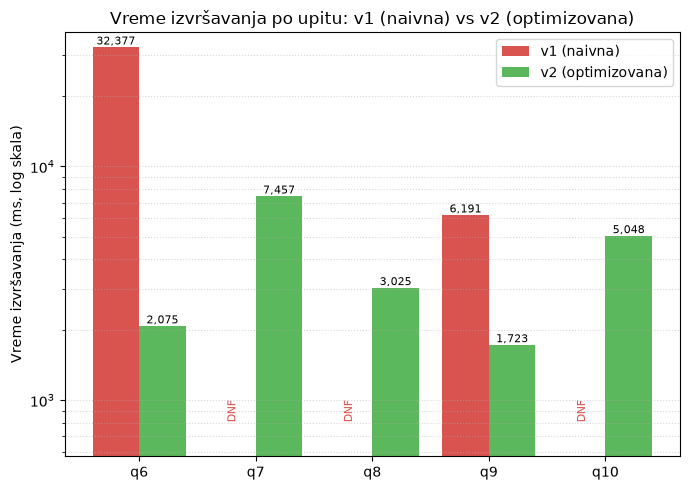


Ukupno trajanje benchmarka: 826.4 s


In [235]:
if __name__ == "__main__" or _in_notebook():
    _results = main()